# Escalado de Features

Cuando las variables tienen escalas muy distintas, el gradiente descendente zigzaguea en lugar de converger directo al mínimo. En este notebook veremos por qué sucede eso, cómo visualizarlo, y cómo corregirlo.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Estilo oscuro coherente con el resto del curso
plt.rcParams.update({
    'figure.facecolor': '#0f0f11',
    'axes.facecolor':   '#0f0f11',
    'axes.edgecolor':   '#2a2a30',
    'axes.labelcolor':  '#8a8a9a',
    'xtick.color':      '#8a8a9a',
    'ytick.color':      '#8a8a9a',
    'text.color':       '#e2e2e8',
    'grid.color':       '#2a2a30',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})

# Carpeta donde se guardan las imágenes para el HTML
# El notebook vive en notebooks/, el HTML en docs/ → los assets van en docs/assets/
ASSETS_DIR = Path("../docs/assets/feature-scaling")
ASSETS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Imágenes se guardarán en: {ASSETS_DIR.resolve()}")

## 1. El problema de las escalas

Generamos dos features con rangos muy distintos: metros cuadrados (500–5000) y número de habitaciones (1–8).

In [31]:
np.random.seed(42)
n = 200

metros       = np.random.uniform(500, 5000, n)
habitaciones = np.random.randint(1, 9, n).astype(float)

# Variable objetivo: precio de la casa
precio = 0.05 * metros + 20 * habitaciones + np.random.randn(n) * 80

print("Feature          min      max      media    std")
print("-" * 55)
for nombre, arr in [("metros", metros), ("habitaciones", habitaciones), ("precio", precio)]:
    print(f"{nombre:<16} {arr.min():6.1f}   {arr.max():6.1f}   {arr.mean():6.1f}   {arr.std():6.1f}")

Feature          min      max      media    std
-------------------------------------------------------
metros            524.8   4941.0   2678.0   1323.7
habitaciones        1.0      8.0      4.6      2.3
precio            -77.6    527.0    231.3    117.3


## 2. Visualizar los contornos de la función de costo

Los contornos muestran qué forma tiene la superficie de pérdida.
- **Sin escalar**: elipses muy alargadas → el gradiente zigzaguea.
- **Con Z-score**: contornos casi circulares → el gradiente apunta directo al mínimo.

Guardado: contornos.png


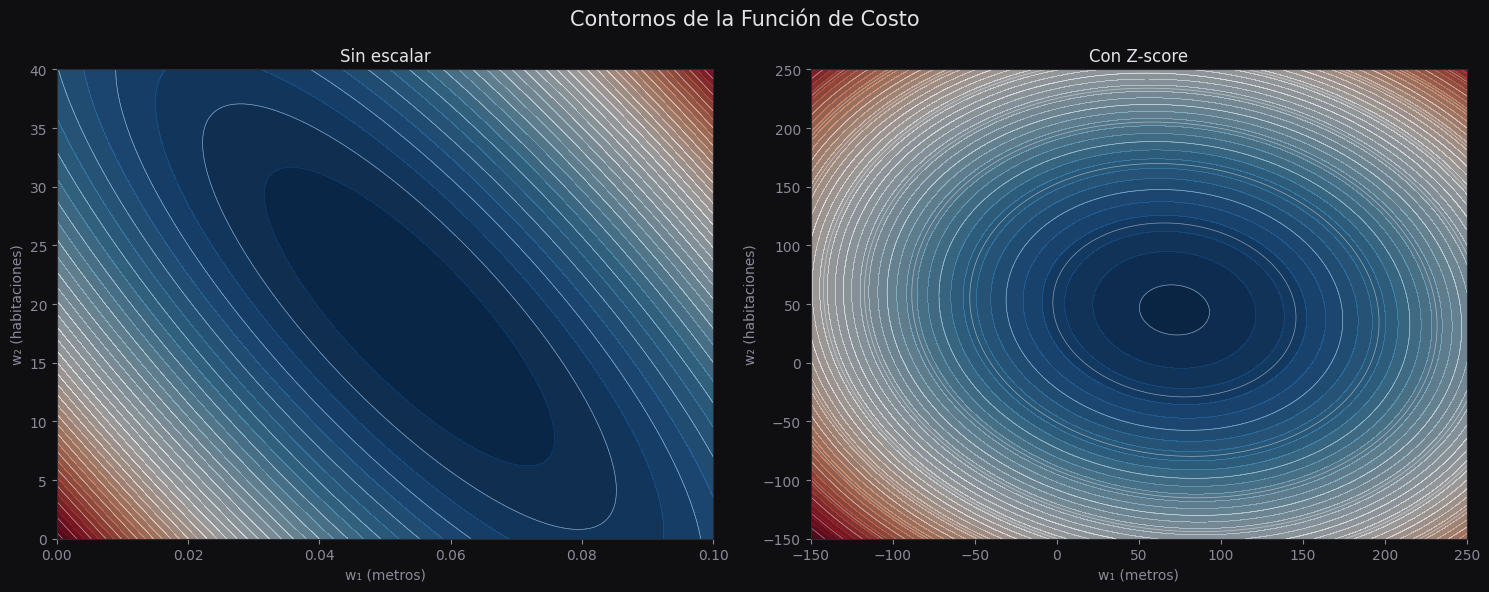

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Funciones base (ajustadas para estabilidad)
def zscore(x):
    return (x - x.mean()) / x.std()

def ecm_grid(w1, w2, X1, X2, y):
    # Error Cuadrático Medio para la malla
    pred = np.outer(w1, X1) + np.outer(w2, X2)
    # Para la malla, calculamos el error para cada combinación de w1, w2
    return ((y - (w1[:, None] * X1 + w2[:, None] * X2))**2).mean(axis=1)

# --- CONFIGURACIÓN DE DATOS ---
# (Asegúrate de que metros, habitaciones y precio estén definidos)
metros_z = zscore(metros)
habitaciones_z = zscore(habitaciones)

# 2. Visualización
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Contornos de la Función de Costo", fontsize=15)

# Definimos configuraciones visuales manuales para "ver" la curva
configs = [
    {
        "x": (metros, habitaciones),
        # Rangos pequeños y centrados para ver la elipse sin escalar
        "w1_range": np.linspace(0.0, 0.1, 200), 
        "w2_range": np.linspace(0, 40, 200),
        "titulo": "Sin escalar"
    },
    {
        "x": (metros_z, habitaciones_z),
        "w1_range": np.linspace(-150, 250, 200),
        "w2_range": np.linspace(-150, 250, 200),
        "titulo": "Con Z-score"
    }
]

for ax, conf in zip(axes, configs):
    x1, x2 = conf["x"]
    wa_range, wb_range = conf["w1_range"], conf["w2_range"]
    WA, WB = np.meshgrid(wa_range, wb_range)
    
    # Cálculo de Z para la superficie (vectorizado para velocidad)
    Z = np.zeros(WA.shape)
    for i in range(WA.shape[0]):
        for j in range(WA.shape[1]):
            Z[i,j] = ((precio - (WA[i,j]*x1 + WB[i,j]*x2))**2).mean()

    # Dibujo de contornos
    ax.contourf(WA, WB, Z, levels=50, cmap="RdBu_r", alpha=0.6)
    cont = ax.contour(WA, WB, Z, levels=20, colors="white", linewidths=0.5, alpha=0.5)
    
    ax.set_title(conf["titulo"])
    ax.set_xlabel("w₁ (metros)")
    ax.set_ylabel("w₂ (habitaciones)")

plt.tight_layout()
plt.savefig(ASSETS_DIR / "contornos.png", dpi=150, bbox_inches="tight", facecolor="#0f0f11")
print("Guardado: contornos.png")
plt.show()

## 3. Métodos de escalado

Implementamos los tres métodos principales y comparamos visualmente su efecto. Se agrega también el **RobustScaler**, que usa mediana e IQR en lugar de media y desviación estándar.

In [ ]:
def escalar_minmax(x):
    """Resultado en [0, 1]."""
    return (x - x.min()) / (x.max() - x.min())

def zscore(x):
    """Media 0, desviación estándar 1."""
    return (x - x.mean()) / x.std()

robust = RobustScaler()
metros_rob = robust.fit_transform(metros.reshape(-1, 1)).ravel()

versiones = [
    (metros,                   "Original"),
    (escalar_minmax(metros),   "Min-Max"),
    (zscore(metros),           "Z-score"),
    (metros_rob,               "RobustScaler"),
]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
fig.suptitle("Efecto de cada método de escalado sobre metros cuadrados", fontsize=12)

for ax, (d, titulo) in zip(axes, versiones):
    ax.hist(d, bins=30, color="#6c7fea", alpha=0.8, edgecolor="#2a2a30", linewidth=0.4)
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel(
        f"med={np.median(d):.2f}  IQR={np.percentile(d,75)-np.percentile(d,25):.2f}",
        fontsize=8
    )

plt.tight_layout()
plt.savefig(ASSETS_DIR / "histogramas.png", dpi=150, bbox_inches="tight", facecolor="#0f0f11")
print("Guardado: histogramas.png")
plt.show()

print("Nota: la FORMA del histograma no cambia, solo los valores del eje x.")

In [ ]:
# Datos normales con un outlier artificial (una propiedad con 95 000 m²)
np.random.seed(42)
datos_normales = np.random.uniform(500, 5000, 199)
datos_con_outlier = np.append(datos_normales, 95000).reshape(-1, 1)

scalers = {
    "Min-Max":      MinMaxScaler(),
    "Z-score":      StandardScaler(),
    "RobustScaler": RobustScaler(),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Efecto de un outlier (95 000 m²) en cada método de escalado", fontsize=12)

for ax, (nombre, scaler) in zip(axes, scalers.items()):
    escalado = scaler.fit_transform(datos_con_outlier).ravel()
    normales = escalado[:-1]   # los 199 puntos normales
    outlier  = escalado[-1]    # el valor extremo

    ax.hist(normales, bins=30, color="#6c7fea", alpha=0.8, edgecolor="#2a2a30", linewidth=0.4)
    ax.axvline(outlier, color="#ea6c6c", linestyle="--", linewidth=1.5,
               label=f"outlier = {outlier:.1f}")
    ax.set_title(nombre, fontsize=10)
    ax.set_xlabel(
        f"med normales={np.median(normales):.2f}  rango=[{normales.min():.2f}, {normales.max():.2f}]",
        fontsize=7.5
    )
    ax.legend(fontsize=8, labelcolor="#e2e2e8")

plt.tight_layout()
plt.show()

print("Min-Max:      datos normales comprimidos en", round(normales.max() - normales.min(), 4),
      "del rango total")
print("Z-score:      media de normales =", round(np.mean(scalers['Z-score'].transform(datos_con_outlier[:-1])[:, 0]), 3))
print("RobustScaler: mediana de normales =", round(np.median(scalers['RobustScaler'].transform(datos_con_outlier[:-1])[:, 0]), 3))

## 3.1 Valores atípicos y escalado

Un único outlier puede distorsionar completamente el resultado del escalado. Veamos cómo reacciona cada método ante un valor extremo.

## 4. Gradiente descendente: con y sin escalado

Entrenamos regresión lineal múltiple con gradiente descendente en ambas versiones.
Compara cuántas iteraciones necesita cada una y con qué learning rate.

Guardado: convergencia.png


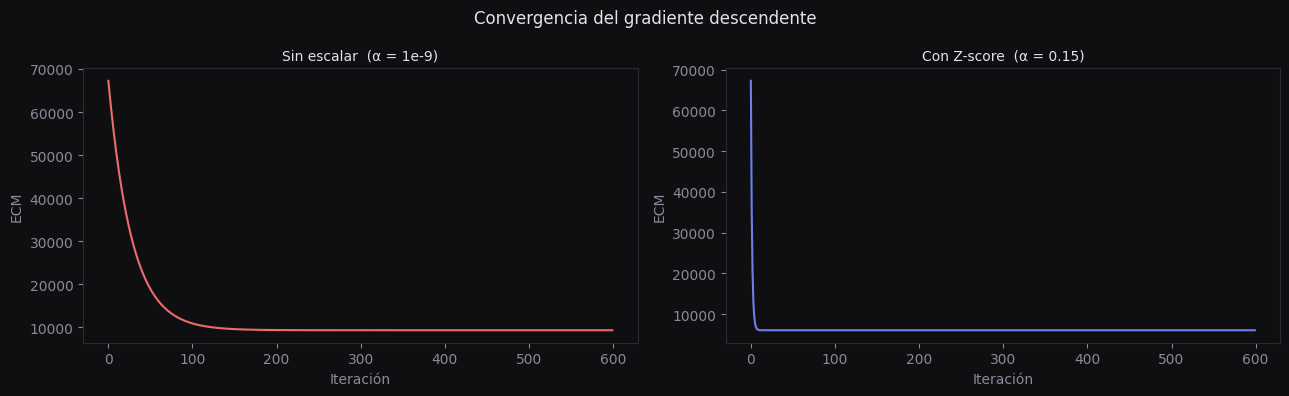

ECM final sin escalar: 9263.59
ECM final con Z-score: 6044.51


In [34]:
def gradiente_paso(w, alpha, X, y):
    """Un paso de gradiente descendente (batch) para regresión lineal."""
    n = len(y)
    pred = X @ w
    grad = (2 / n) * X.T @ (pred - y)
    return w - alpha * grad

def entrenar(X, y, alpha, n_iter=600):
    """Devuelve los pesos finales y el historial de ECM."""
    w = np.zeros(X.shape[1])
    hist = []
    for _ in range(n_iter):
        pred = X @ w
        hist.append(((y - pred) ** 2).mean())
        w = gradiente_paso(w, alpha, X, y)
    return w, hist

# Preparar matrices (con columna de bias)
bias  = np.ones(n)
X_raw = np.column_stack([bias, metros,          habitaciones])
X_sc  = np.column_stack([bias, zscore(metros),  zscore(habitaciones)])

w_raw, hist_raw = entrenar(X_raw, precio, alpha=1e-9)
w_sc,  hist_sc  = entrenar(X_sc,  precio, alpha=0.15)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Convergencia del gradiente descendente", fontsize=12)

axes[0].plot(hist_raw, color="#ea6c6c", linewidth=1.5)
axes[0].set_title("Sin escalar  (α = 1e-9)", fontsize=10)
axes[0].set_xlabel("Iteración")
axes[0].set_ylabel("ECM")

axes[1].plot(hist_sc, color="#6c7fea", linewidth=1.5)
axes[1].set_title("Con Z-score  (α = 0.15)", fontsize=10)
axes[1].set_xlabel("Iteración")
axes[1].set_ylabel("ECM")

plt.tight_layout()
plt.savefig(ASSETS_DIR / "convergencia.png", dpi=150, bbox_inches="tight", facecolor="#0f0f11")
print("Guardado: convergencia.png")
plt.show()

print(f"ECM final sin escalar: {hist_raw[-1]:.2f}")
print(f"ECM final con Z-score: {hist_sc[-1]:.2f}")

## 5. Cómo escalar correctamente: train/test

**Regla**: ajustar el escalador solo con datos de entrenamiento, luego aplicarlo a ambos conjuntos.
Si usas el dataset completo para calcular la media y std, filtras información del test al entrenamiento (data leakage).

In [35]:
# Construir matriz de features
X = np.column_stack([metros, habitaciones])

# 1. Dividir PRIMERO
X_train, X_test, y_train, y_test = train_test_split(
    X, precio, test_size=0.2, random_state=42
)

# 2. Ajustar escalador SOLO sobre train
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)

# 3. Aplicar a test usando los parámetros de train
X_test_sc = scaler.transform(X_test)

print("Parámetros aprendidos del entrenamiento:")
print(f"  Media:  {scaler.mean_}")
print(f"  Std:    {scaler.scale_}")
print()
print("Train escalado — media por feature:", X_train_sc.mean(axis=0).round(4))
print("Test  escalado — media por feature:", X_test_sc.mean(axis=0).round(4))
print()
print("(El test no tiene media exactamente 0 — eso es correcto y esperado)")

Parámetros aprendidos del entrenamiento:
  Media:  [2668.30117385    4.675     ]
  Std:    [1323.11450018    2.33331845]

Train escalado — media por feature: [0. 0.]
Test  escalado — media por feature: [ 0.0368 -0.0857]

(El test no tiene media exactamente 0 — eso es correcto y esperado)


## 6. Ejercicios

1. Carga el dataset `data/csvs/examenes.csv`. Elige dos variables numéricas y visualiza sus distribuciones. ¿Tienen rangos similares?

2. Aplica los tres métodos de escalado (min-max, media, z-score) a las variables que elegiste. Grafica los histogramas comparados.

3. Entrena un modelo de regresión lineal múltiple con gradiente descendente usando esas dos variables como features. Compara la convergencia con y sin escalado. ¿Cuál learning rate usas en cada caso?

4. Implementa el flujo completo: divide en train/test, ajusta el escalador solo en train y aplícalo a ambos conjuntos. Evalúa el ECM en test.

In [36]:
# Ejercicio 1
df = pd.read_csv("../data/csvs/examenes.csv")
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [37]:
# Ejercicio 2 — tu código aquí


In [38]:
# Ejercicio 3 — tu código aquí


In [39]:
# Ejercicio 4 — tu código aquí
